# Drift Characterization -- FALCON H1 Dataset

**Week 1 Deliverable (Rishab)**

Before modeling, we need to confirm that neural drift actually exists in the FALCON H1 dataset and understand what it looks like. We perform three analyses:

1. **Firing rate distributions per neuron across sessions** -- quantify how much individual neurons shift
2. **Pairwise session correlations** -- measure population-level drift as a function of temporal distance
3. **PCA projections per session colored by reach direction** -- test whether low-dimensional structure is preserved despite single-neuron changes

**Hypothesis (Gallego et al., 2020):** Individual neurons shift substantially across sessions, but population-level latent dynamics (e.g., directional tuning) remain stable. This would support the idea that representational drift reflects geometric transformations of a stable low-dimensional manifold, rather than a fundamentally new neural code.

In [1]:
from __future__ import annotations

import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pynwb import NWBHDF5IO

from falcon_challenge.config import H1_NEW_TO_OLD
from falcon_challenge.dataloaders import bin_units
from data_demos.styleguide import set_style

set_style()

# ---- Constants (matching fm_decoder.ipynb pipeline) ----
BIN_SIZE_S = 0.02           # 50 Hz
BIN_SIZE_MS = BIN_SIZE_S * 1000
N_CHANNELS = 176
N_PCA = 32

## Data Loading

Load all H1 NWB files and organize by session. Each session (S0--S12) may contain 2--3 calibration sets which we concatenate within the session.

Preprocessing functions are adapted from `models/fm_decoder.ipynb` to stay consistent with the decoder pipeline.

In [2]:
# ---- Preprocessing helpers (from fm_decoder.ipynb) ----

def apply_exponential_filter(binned: np.ndarray, tau_ms: float = 20.0) -> np.ndarray:
    """Causal exponential filter matching fm_decoder pipeline (tau=20ms)."""
    alpha = 1.0 - np.exp(-BIN_SIZE_MS / tau_ms)
    out = np.zeros_like(binned, dtype=np.float32)
    out[0] = alpha * binned[0]
    for t in range(1, len(binned)):
        out[t] = alpha * binned[t] + (1.0 - alpha) * out[t - 1]
    return out


def create_targets(kin: np.ndarray, target_smooth_ms: float = 490.0) -> np.ndarray:
    """Smoothed velocity targets (smooth + gradient)."""
    sigma = target_smooth_ms / (3.0 * BIN_SIZE_MS)
    smoothed = gaussian_filter1d(kin.astype(np.float32), sigma=sigma, axis=0)
    return np.gradient(smoothed, axis=0).astype(np.float32)


# ---- NWB loader (adapted from fm_decoder / h1.ipynb) ----

def load_nwb_h1(fn: str):
    """Load a single H1 NWB file. Returns binned spikes, raw kinematics, and session date."""
    with NWBHDF5IO(fn, "r") as io:
        nwb = io.read()
        units = nwb.units.to_dataframe()
        kin = nwb.acquisition["OpenLoopKinematics"].data[:]
        rate = nwb.acquisition["OpenLoopKinematics"].rate
        offset = nwb.acquisition["OpenLoopKinematics"].offset
        timestamps = offset + np.arange(kin.shape[0]) * rate
        blacklist = ~nwb.acquisition["eval_mask"].data[:].astype(bool)
        date_str = nwb.session_start_time.strftime("%m-%d")

    binned = bin_units(units, bin_size_s=BIN_SIZE_S, bin_timestamps=timestamps)
    return binned.astype(np.float32), kin.astype(np.float32), blacklist, date_str


# ---- Discover data directory (support both h1.ipynb and fm_decoder layouts) ----

def find_nwb_files(query: str) -> list[str]:
    """Find NWB files for a given subject query, supporting multiple directory layouts."""
    # Layout 1: data/000954/<query>/*.nwb  (h1.ipynb / dandi download)
    path1 = Path("data/000954") / query
    # Layout 2: data/h1/*/<query>/*.nwb  (fm_decoder.ipynb)
    path2 = Path("data/h1")

    files = []
    for base in [path1, path2]:
        if base.exists():
            for f in sorted(base.rglob("*.nwb")):
                if query in str(f):
                    files.append(str(f))
    if not files:
        raise FileNotFoundError(
            f"No NWB files found for '{query}'. "
            f"Run: dandi download https://dandiarchive.org/dandiset/000954/draft"
        )
    return sorted(set(files))


# ---- Load and group by session ----

train_query = "sub-HumanPitt-held-in-calib"
test_query = "sub-HumanPitt-held-out-calib"

train_files = find_nwb_files(train_query)
test_files = find_nwb_files(test_query)
print(f"Found {len(train_files)} train files, {len(test_files)} test files")

# Build per-session data structure
sessions = {}

for fn_list, split in [(train_files, "train"), (test_files, "test")]:
    for fn in fn_list:
        # Extract session timestamp from filename to look up session ID
        stem = Path(fn).stem
        ses_key = stem.split("_ses-")[-1] if "_ses-" in stem else None

        if ses_key and ses_key in H1_NEW_TO_OLD:
            full_id = H1_NEW_TO_OLD[ses_key]          # e.g. "S0_set_1"
            session_id = full_id.split("_set")[0]      # e.g. "S0"
        else:
            # Fallback: use filename date portion
            session_id = stem.split("_")[1] if "_" in stem else stem
            full_id = session_id

        binned, kin, blacklist, date_str = load_nwb_h1(fn)
        print(f"  {Path(fn).name}: {session_id} ({date_str}), T={binned.shape[0]}, split={split}")

        if session_id not in sessions:
            sessions[session_id] = {
                "neural": [], "kin": [], "blacklist": [],
                "split": split, "date_str": date_str,
            }
        sessions[session_id]["neural"].append(binned)
        sessions[session_id]["kin"].append(kin)
        sessions[session_id]["blacklist"].append(blacklist)

# Concatenate calibration sets within each session
for sid in sessions:
    sessions[sid]["neural"] = np.concatenate(sessions[sid]["neural"], axis=0)
    sessions[sid]["kin"] = np.concatenate(sessions[sid]["kin"], axis=0)
    sessions[sid]["blacklist"] = np.concatenate(sessions[sid]["blacklist"], axis=0)

# Sort by session number
session_ids = sorted(sessions.keys(), key=lambda x: int(x[1:]))

# Summary table
print(f"\n{'Session':<10} {'Date':<8} {'Split':<8} {'Timesteps':>10} {'Duration (s)':>12} {'Channels':>10}")
print("-" * 62)
for sid in session_ids:
    s = sessions[sid]
    T = s["neural"].shape[0]
    print(f"{sid:<10} {s['date_str']:<8} {s['split']:<8} {T:>10} {T * BIN_SIZE_S:>12.1f} {s['neural'].shape[1]:>10}")
print(f"\nTotal sessions: {len(session_ids)}")

Found 13 train files, 14 test files
  sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb: S0 (01-01), T=10819, split=train
  sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb: S0 (01-01), T=6456, split=train
  sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb: S1 (01-08), T=12233, split=train
  sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb: S1 (01-08), T=6786, split=train
  sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb: S1 (01-08), T=6505, split=train
  sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb: S2 (01-13), T=11646, split=train
  sub-HumanPitt-held-in-calib_ses-19250113T121303.nwb: S2 (01-13), T=11732, split=train
  sub-HumanPitt-held-in-calib_ses-19250115T110633.nwb: S3 (01-15), T=10071, split=train
  sub-HumanPitt-held-in-calib_ses-19250115T111328.nwb: S3 (01-15), T=12267, split=train
  sub-HumanPitt-held-in-calib_ses-19250119T113543.nwb: S4 (01-19), T=11951, split=train
  sub-HumanPitt-held-in-calib_ses-19250119T114045.nwb: S4 (01-19), T=12022, split=train

## Analysis 1: Firing Rate Distributions Per Neuron Across Sessions

For each session, compute the mean firing rate per neuron (converting from spike counts to Hz). We expect individual neurons to shift substantially across sessions due to electrode drift, impedance changes, and neural reorganization.

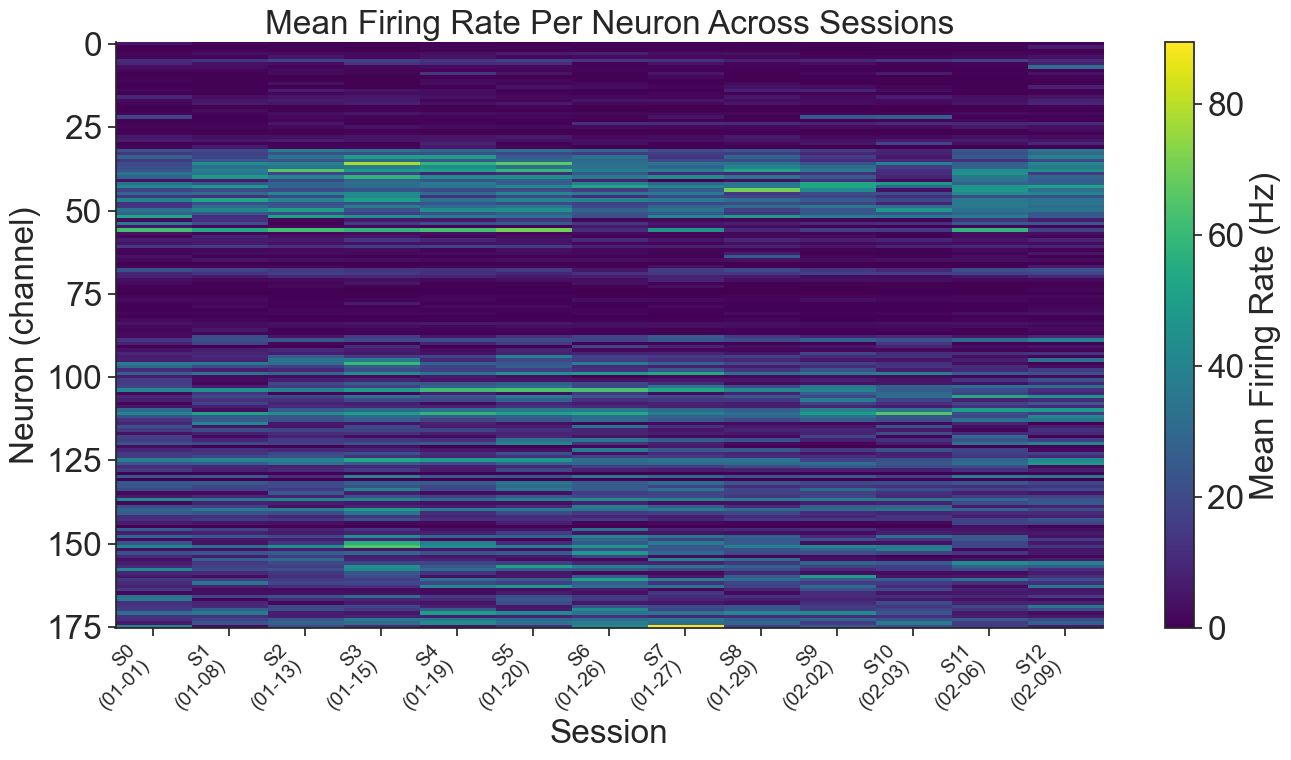

In [3]:
# Compute mean firing rate per neuron per session (Hz)
n_sessions = len(session_ids)
n_neurons = sessions[session_ids[0]]["neural"].shape[1]

fr_matrix = np.zeros((n_neurons, n_sessions))
for j, sid in enumerate(session_ids):
    fr_matrix[:, j] = sessions[sid]["neural"].mean(axis=0) / BIN_SIZE_S  # spike counts -> Hz

# ---- Figure 1a: Heatmap (neuron x session) ----
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(fr_matrix, aspect="auto", cmap="viridis", interpolation="nearest")
ax.set_xlabel("Session")
ax.set_ylabel("Neuron (channel)")
ax.set_xticks(range(n_sessions))
ax.set_xticklabels(
    [f"{sid}\n({sessions[sid]['date_str']})" for sid in session_ids],
    rotation=45, ha="right", fontsize=14,
)
cbar = plt.colorbar(im, ax=ax, label="Mean Firing Rate (Hz)")
ax.set_title("Mean Firing Rate Per Neuron Across Sessions")
plt.tight_layout()
plt.show()

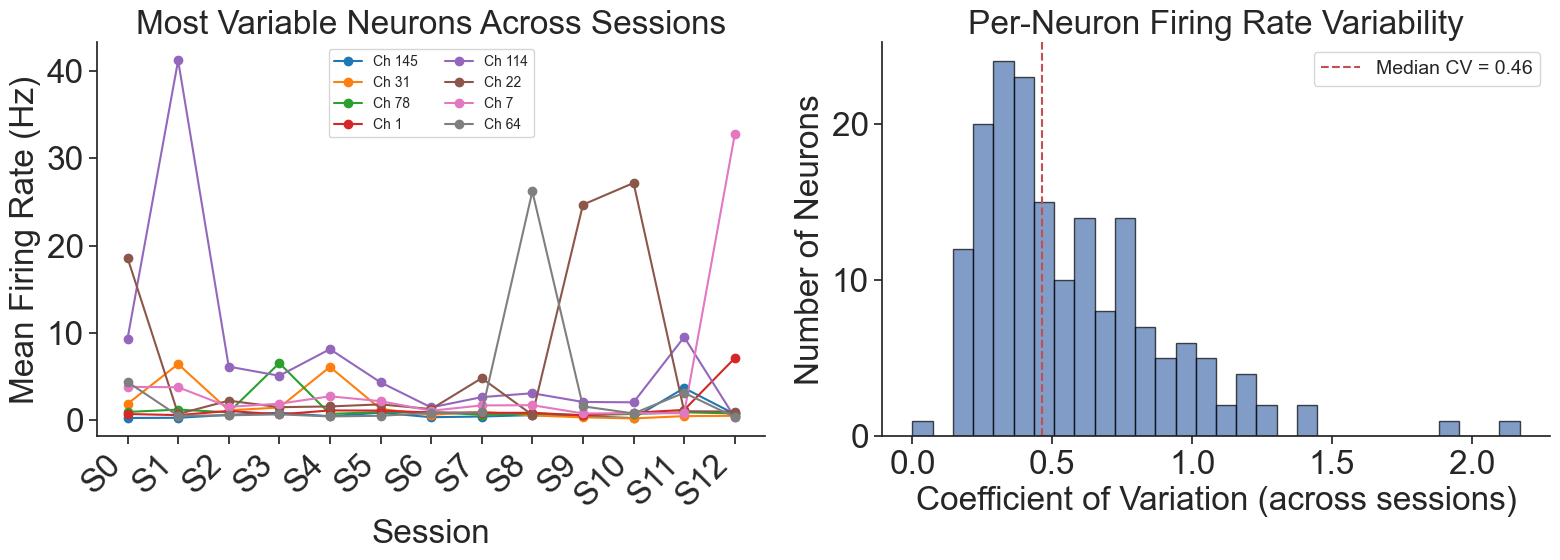

Median CV across sessions:         0.463
Mean CV across sessions:           0.565
Fraction of neurons with CV > 0.3: 80.1%
Fraction of neurons with CV > 0.5: 46.6%
Fraction of neurons with CV > 1.0: 10.2%


In [4]:
# ---- Figure 1b: Per-neuron variability ----

# Coefficient of variation across sessions for each neuron
cv_per_neuron = fr_matrix.std(axis=1) / (fr_matrix.mean(axis=1) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: trajectories of 8 most variable neurons
high_var_neurons = np.argsort(cv_per_neuron)[-8:]
palette = sns.color_palette("tab10", n_colors=8)
for i, neuron_idx in enumerate(high_var_neurons):
    axes[0].plot(
        range(n_sessions), fr_matrix[neuron_idx, :],
        marker="o", color=palette[i], label=f"Ch {neuron_idx}",
    )
axes[0].set_xticks(range(n_sessions))
axes[0].set_xticklabels([sid for sid in session_ids], rotation=45, ha="right")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Mean Firing Rate (Hz)")
axes[0].set_title("Most Variable Neurons Across Sessions")
axes[0].legend(fontsize=10, ncol=2)

# Right: histogram of CV values
axes[1].hist(cv_per_neuron, bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(
    np.median(cv_per_neuron), color="r", linestyle="--",
    label=f"Median CV = {np.median(cv_per_neuron):.2f}",
)
axes[1].set_xlabel("Coefficient of Variation (across sessions)")
axes[1].set_ylabel("Number of Neurons")
axes[1].set_title("Per-Neuron Firing Rate Variability")
axes[1].legend(fontsize=14)

plt.tight_layout()
plt.show()

# Quantitative summary
print(f"Median CV across sessions:         {np.median(cv_per_neuron):.3f}")
print(f"Mean CV across sessions:           {np.mean(cv_per_neuron):.3f}")
print(f"Fraction of neurons with CV > 0.3: {(cv_per_neuron > 0.3).mean():.1%}")
print(f"Fraction of neurons with CV > 0.5: {(cv_per_neuron > 0.5).mean():.1%}")
print(f"Fraction of neurons with CV > 1.0: {(cv_per_neuron > 1.0).mean():.1%}")

## Analysis 2: Pairwise Session Correlations

For each pair of sessions, compute the Pearson correlation between their 176-dimensional mean firing rate vectors. This captures how much the overall population activity profile drifts. We also plot correlation vs. temporal distance to test whether drift increases over time.

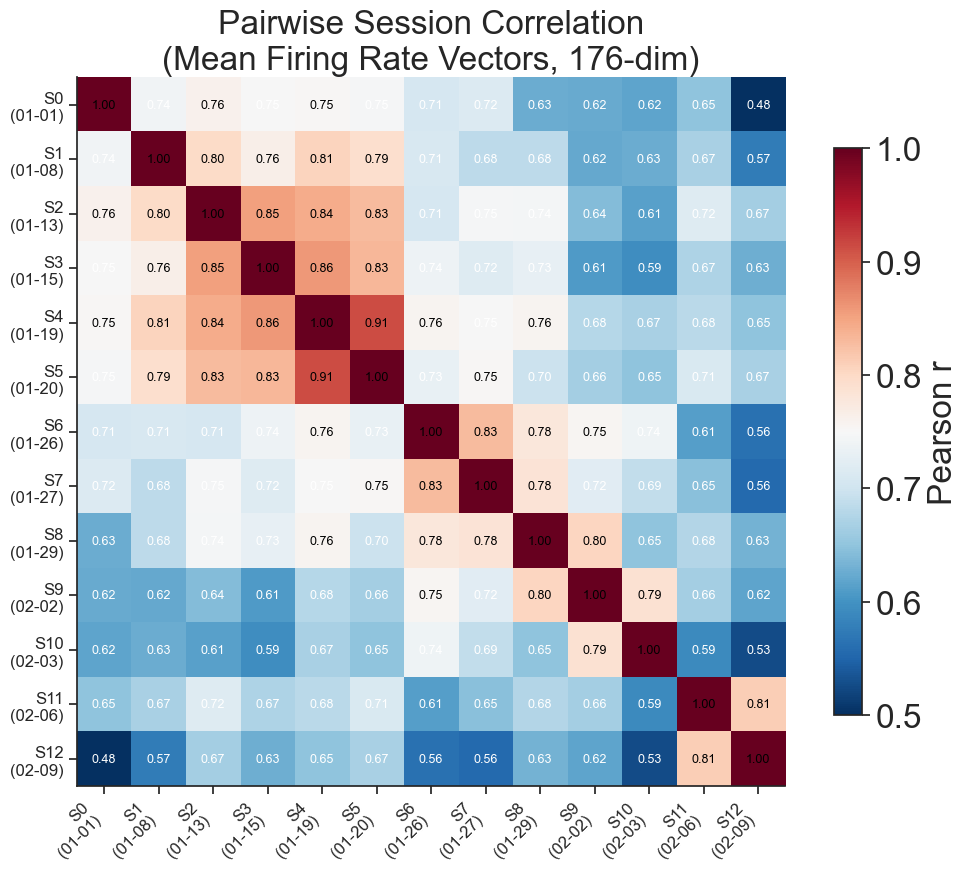

In [5]:
# ---- Pairwise correlation matrix ----
corr_matrix = np.zeros((n_sessions, n_sessions))
for i in range(n_sessions):
    for j in range(n_sessions):
        r, _ = pearsonr(fr_matrix[:, i], fr_matrix[:, j])
        corr_matrix[i, j] = r

# ---- Figure 2a: Correlation matrix heatmap ----
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=0.5, vmax=1.0)
ax.set_xticks(range(n_sessions))
ax.set_yticks(range(n_sessions))
labels = [f"{sid}\n({sessions[sid]['date_str']})" for sid in session_ids]
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
ax.set_yticklabels(labels, fontsize=12)
plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)
ax.set_title("Pairwise Session Correlation\n(Mean Firing Rate Vectors, 176-dim)")

# Annotate cells
for i in range(n_sessions):
    for j in range(n_sessions):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if corr_matrix[i, j] < 0.75 else "black")

plt.tight_layout()
plt.show()

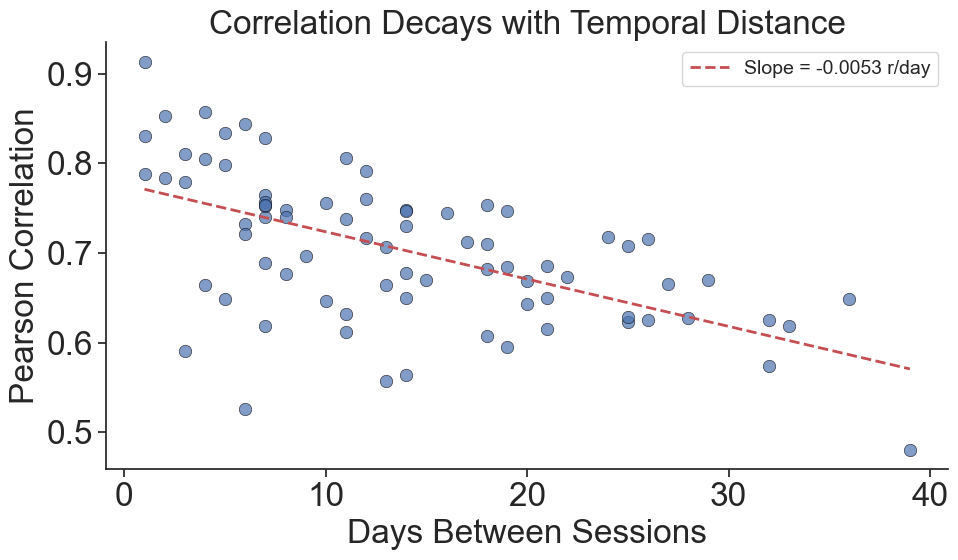

Mean off-diagonal correlation:     0.703
Min pairwise correlation:          0.480
Max pairwise correlation:          0.913
Correlation decay slope:           -0.00527 r/day
Correlation at 0 days (intercept): 0.776


In [6]:
# ---- Figure 2b: Correlation vs. temporal distance ----

from datetime import datetime

# Parse session dates (obfuscated 1925 dates)
session_dates = {}
for sid in session_ids:
    date_str = sessions[sid]["date_str"]  # e.g. "01-01"
    session_dates[sid] = datetime.strptime(f"1925-{date_str}", "%Y-%m-%d")

temporal_distances = []
correlations = []
pair_labels = []

for i in range(n_sessions):
    for j in range(i + 1, n_sessions):
        days_apart = abs((session_dates[session_ids[j]] - session_dates[session_ids[i]]).days)
        temporal_distances.append(days_apart)
        correlations.append(corr_matrix[i, j])
        pair_labels.append(f"{session_ids[i]}-{session_ids[j]}")

temporal_distances = np.array(temporal_distances)
correlations = np.array(correlations)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(temporal_distances, correlations, alpha=0.7, s=80, edgecolors="black", linewidths=0.5)
ax.set_xlabel("Days Between Sessions")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Correlation Decays with Temporal Distance")

# Linear trend
z = np.polyfit(temporal_distances, correlations, 1)
p = np.poly1d(z)
x_range = np.linspace(temporal_distances.min(), temporal_distances.max(), 100)
ax.plot(x_range, p(x_range), "r--", linewidth=2, label=f"Slope = {float(z[0]):.4f} r/day")
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Quantitative summary
off_diag = corr_matrix[np.triu_indices(n_sessions, k=1)]
print(f"Mean off-diagonal correlation:     {off_diag.mean():.3f}")
print(f"Min pairwise correlation:          {off_diag.min():.3f}")
print(f"Max pairwise correlation:          {off_diag.max():.3f}")
print(f"Correlation decay slope:           {float(z[0]):.5f} r/day")
print(f"Correlation at 0 days (intercept): {float(z[1]):.3f}")

## Analysis 3: PCA Projections Per Session

We fit PCA on exponentially-filtered training data to find a shared low-dimensional subspace, then project all sessions into it. If population-level structure is preserved despite single-neuron drift, different sessions should overlap in PCA space and reach directions should cluster consistently across sessions.

This tests the key prediction from Gallego et al. (2020): latent dynamics are stable even when individual neurons change.

In [7]:
# ---- Step 1: Exponential filter all sessions ----
filtered_sessions = {}
for sid in session_ids:
    filtered_sessions[sid] = apply_exponential_filter(sessions[sid]["neural"])

# ---- Step 2: Fit PCA on training sessions only ----
train_sids = [sid for sid in session_ids if sessions[sid]["split"] == "train"]
test_sids = [sid for sid in session_ids if sessions[sid]["split"] == "test"]
print(f"Train sessions: {train_sids}")
print(f"Test sessions:  {test_sids}")

# Z-score using training statistics
train_filtered = np.concatenate([filtered_sessions[sid] for sid in train_sids], axis=0)
scaler = StandardScaler()
scaler.fit(train_filtered)

train_filtered_z = scaler.transform(train_filtered)

# Fit PCA
pca = PCA(n_components=N_PCA)
pca.fit(train_filtered_z)

print(f"\nVariance explained by {N_PCA} PCs: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Variance explained by top 3 PCs:  {pca.explained_variance_ratio_[:3].sum():.3f}")
print(f"Variance explained by top 10 PCs: {pca.explained_variance_ratio_[:10].sum():.3f}")

# ---- Step 3: Project all sessions ----
projected = {}
for sid in session_ids:
    scaled = scaler.transform(filtered_sessions[sid])
    projected[sid] = pca.transform(scaled)

Train sessions: ['S0', 'S1', 'S2', 'S3', 'S4', 'S5']
Test sessions:  ['S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12']

Variance explained by 32 PCs: 0.307
Variance explained by top 3 PCs:  0.076
Variance explained by top 10 PCs: 0.166


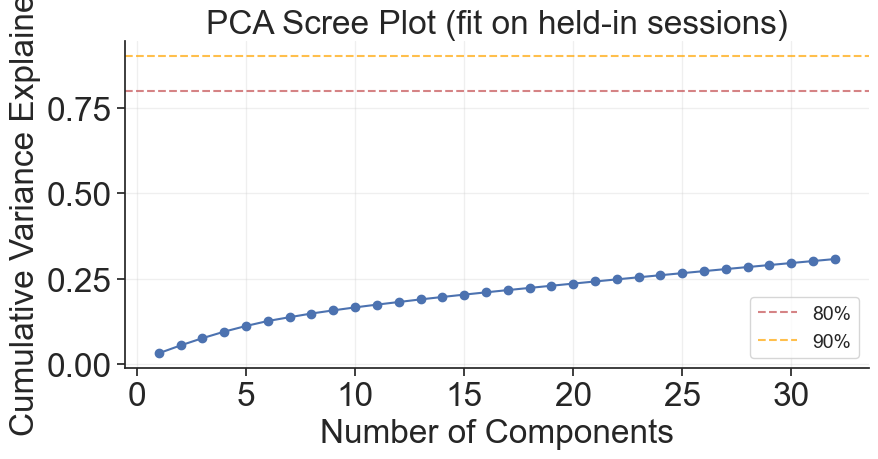

  60% variance -> 32 components
  70% variance -> 32 components
  80% variance -> 32 components
  90% variance -> 32 components
  95% variance -> 32 components


In [8]:
# ---- Figure 3a: Scree plot ----
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, N_PCA + 1), cumvar, "o-", markersize=6)
ax.axhline(0.80, color="r", linestyle="--", alpha=0.7, label="80%")
ax.axhline(0.90, color="orange", linestyle="--", alpha=0.7, label="90%")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Variance Explained")
ax.set_title("PCA Scree Plot (fit on held-in sessions)")
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for threshold in [0.60, 0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(cumvar >= threshold) + 1 if (cumvar >= threshold).any() else N_PCA
    print(f"  {threshold:.0%} variance -> {n} components")

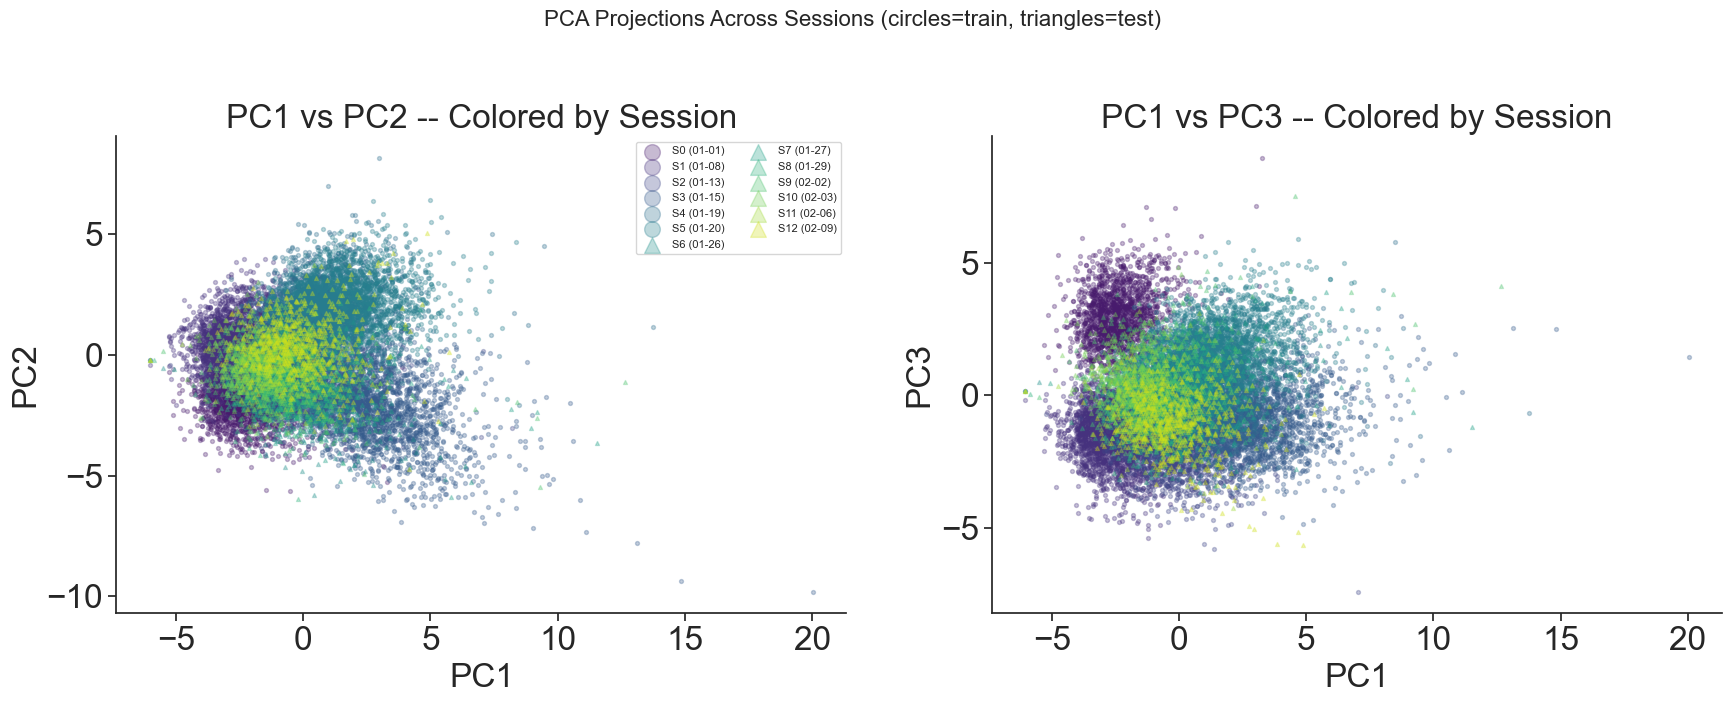

In [9]:
# ---- Figure 3b: PC1 vs PC2 and PC1 vs PC3, colored by session ----

SUBSAMPLE = 10  # Plot every 10th point to avoid overplotting
palette = sns.color_palette("viridis", n_colors=n_sessions)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, sid in enumerate(session_ids):
    proj = projected[sid][::SUBSAMPLE]
    marker = "o" if sessions[sid]["split"] == "train" else "^"
    label = f"{sid} ({sessions[sid]['date_str']})"

    axes[0].scatter(proj[:, 0], proj[:, 1], c=[palette[idx]], s=8, alpha=0.3,
                    marker=marker, label=label)
    axes[1].scatter(proj[:, 0], proj[:, 2], c=[palette[idx]], s=8, alpha=0.3,
                    marker=marker, label=label)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PC1 vs PC2 -- Colored by Session")
axes[0].legend(markerscale=4, fontsize=8, ncol=2, loc="upper right")

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")
axes[1].set_title("PC1 vs PC3 -- Colored by Session")

fig.suptitle("PCA Projections Across Sessions (circles=train, triangles=test)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

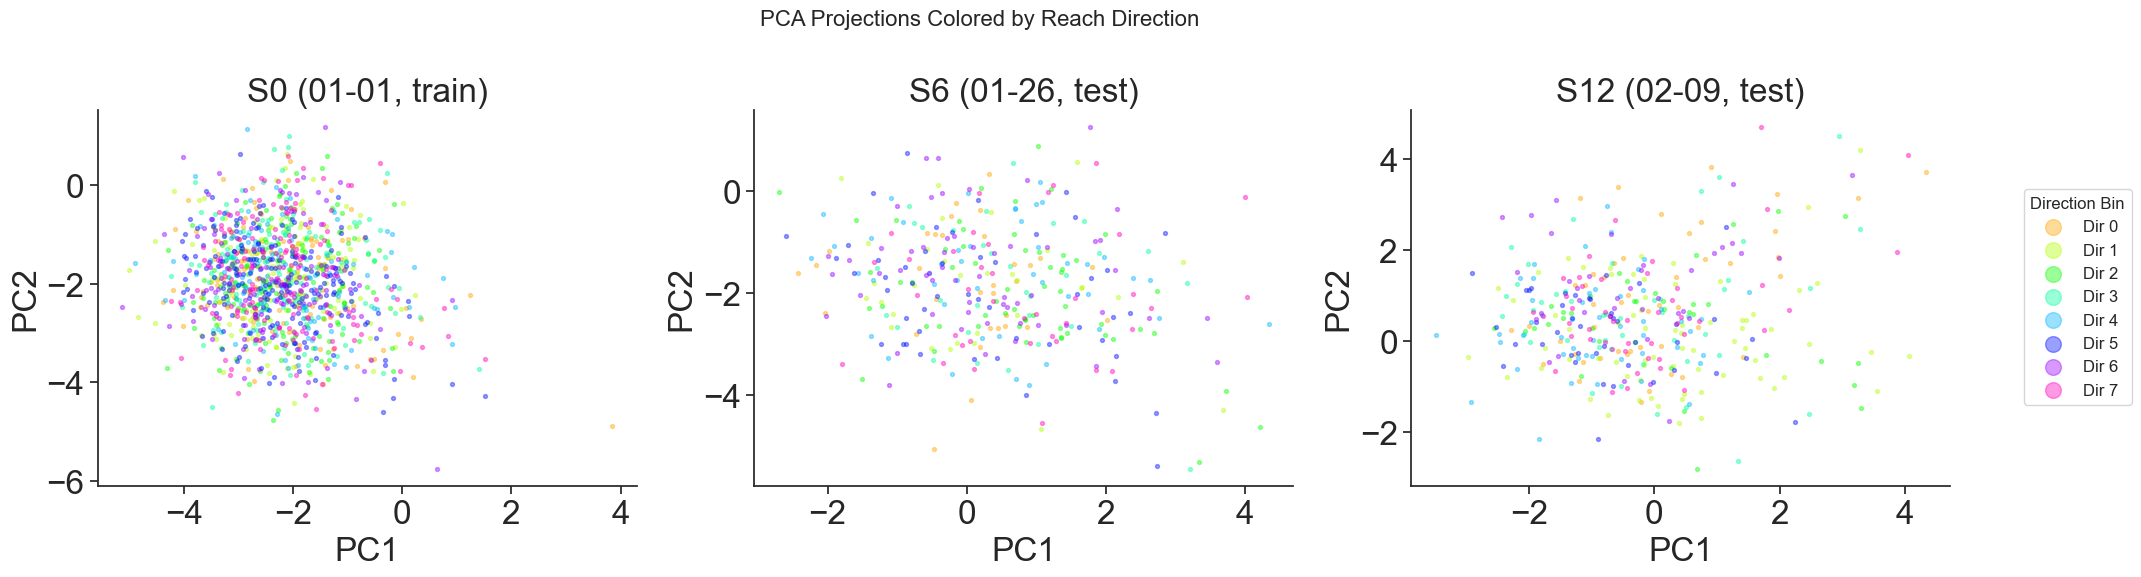

In [10]:
# ---- Figure 3c: PCA colored by reach direction ----
# Use first 3 DoFs (translation) to compute 2D reach direction via arctan2

def compute_reach_direction(kin: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Compute discretized reach direction from translation velocity (first 3 DoFs)."""
    vel = create_targets(kin)  # Smoothed velocity
    # 2D angle from translation x,y velocity
    angles = np.arctan2(vel[:, 1], vel[:, 0])
    # Discretize into 8 direction bins
    n_bins = 8
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    direction_labels = np.digitize(angles, bin_edges) - 1
    direction_labels = np.clip(direction_labels, 0, n_bins - 1)
    # Speed for filtering out stationary timepoints
    speed = np.sqrt((vel[:, :3] ** 2).sum(axis=1))
    return direction_labels, speed


# Pick 3 example sessions: early, middle, late
demo_sids = [session_ids[0], session_ids[n_sessions // 2], session_ids[-1]]
direction_palette = sns.color_palette("hsv", n_colors=8)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, sid in zip(axes, demo_sids):
    dir_labels, speed = compute_reach_direction(sessions[sid]["kin"])
    proj = projected[sid]

    # Only plot moving timepoints (above 30th percentile speed)
    speed_thresh = np.percentile(speed, 30)
    moving = speed > speed_thresh

    for d in range(8):
        mask = (dir_labels == d) & moving
        if mask.sum() > 0:
            ax.scatter(
                proj[mask, 0][::SUBSAMPLE], proj[mask, 1][::SUBSAMPLE],
                c=[direction_palette[d]], s=8, alpha=0.4, label=f"Dir {d}",
            )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{sid} ({sessions[sid]['date_str']}, {sessions[sid]['split']})")

# Single legend for all panels
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="center right", markerscale=4, fontsize=12,
           title="Direction Bin", bbox_to_anchor=(1.08, 0.5))
fig.suptitle("PCA Projections Colored by Reach Direction", fontsize=16)
plt.tight_layout()
plt.show()

## Summary

**Key findings from the three drift analyses:**

In [11]:
print("=" * 65)
print("DRIFT CHARACTERIZATION SUMMARY")
print("=" * 65)

print("\n--- Analysis 1: Single-Neuron Firing Rate Variability ---")
print(f"  Median CV across sessions:         {np.median(cv_per_neuron):.3f}")
print(f"  Fraction of neurons with CV > 0.3: {(cv_per_neuron > 0.3).mean():.1%}")
print(f"  Fraction of neurons with CV > 0.5: {(cv_per_neuron > 0.5).mean():.1%}")

print("\n--- Analysis 2: Pairwise Session Correlations ---")
print(f"  Mean pairwise correlation:         {off_diag.mean():.3f}")
print(f"  Min / Max correlation:             {off_diag.min():.3f} / {off_diag.max():.3f}")
print(f"  Decay slope:                       {float(z[0]):.5f} r/day")

print("\n--- Analysis 3: PCA Latent Structure ---")
print(f"  Variance explained (top 3 PCs):    {pca.explained_variance_ratio_[:3].sum():.3f}")
print(f"  Variance explained ({N_PCA} PCs):     {pca.explained_variance_ratio_.sum():.3f}")

print("\n--- Interpretation ---")
print("""
If individual neurons show high CV but pairwise session correlations
remain moderate-to-high, this supports the Gallego et al. (2020)
hypothesis: single-neuron activity is unstable, but population-level
structure is preserved.

If PCA projections show consistent directional clustering across
sessions (even those far apart in time), this further confirms that
representational drift reflects geometric transformations of a stable
low-dimensional manifold, not a fundamentally new code.

This motivates our modeling approach: a flow matching decoder that
exploits geometric structure should be more robust to this kind of
drift than a linear baseline.
""")

DRIFT CHARACTERIZATION SUMMARY

--- Analysis 1: Single-Neuron Firing Rate Variability ---
  Median CV across sessions:         0.463
  Fraction of neurons with CV > 0.3: 80.1%
  Fraction of neurons with CV > 0.5: 46.6%

--- Analysis 2: Pairwise Session Correlations ---
  Mean pairwise correlation:         0.703
  Min / Max correlation:             0.480 / 0.913
  Decay slope:                       -0.00527 r/day

--- Analysis 3: PCA Latent Structure ---
  Variance explained (top 3 PCs):    0.076
  Variance explained (32 PCs):     0.307

--- Interpretation ---

If individual neurons show high CV but pairwise session correlations
remain moderate-to-high, this supports the Gallego et al. (2020)
hypothesis: single-neuron activity is unstable, but population-level
structure is preserved.

If PCA projections show consistent directional clustering across
sessions (even those far apart in time), this further confirms that
representational drift reflects geometric transformations of a stable
lo